<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/Implementation_plan_for_BJudge_%26_Multi_Rollout_CUA_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# [CELL 1 - Dependencies & Environment Setup]
!pip install -q transformers torch matplotlib datasets pandas

import torch
import torch.nn as nn
import torch.nn.functional as F
import json
import re
import random
import matplotlib.pyplot as plt
from typing import List, Dict, Any

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print("BJudge (Behavior Judge for Computer-Use Agents) environment initialized.")

PyTorch Version: 2.11.0+cu130
CUDA Available: True
BJudge (Behavior Judge for Computer-Use Agents) environment initialized.


In [2]:
# [CELL 2 - OSWorld-style Multi-Rollout Trajectory Generator]

OSWORLD_TASKS = [
    {
        "task_id": "osworld_001",
        "instruction": "Open Thunderbird, find the email with subject 'Quarterly Budget', extract the attached CSV, calculate the total expense in LibreOffice Calc, and save the result to ~/Desktop/total.txt",
        "ground_truth_target": "Total Expense: $42,850.00",
        "milestones": [
            "Open Thunderbird email client",
            "Locate email 'Quarterly Budget'",
            "Download attached CSV file",
            "Open CSV in LibreOffice Calc",
            "Calculate total expense sum",
            "Save total sum to ~/Desktop/total.txt"
        ]
    },
    {
        "task_id": "osworld_002",
        "instruction": "Open Chrome, navigate to localhost:8080/admin, log in as admin, export the user activity log as JSON, and move it to /var/log/exports/",
        "ground_truth_target": "Exported 142 records to /var/log/exports/activity_log.json",
        "milestones": [
            "Open Chrome browser",
            "Navigate to admin portal",
            "Authenticate as admin",
            "Export user activity log JSON",
            "Move exported file to /var/log/exports/"
        ]
    }
]

def generate_simulated_rollout(task: Dict[str, Any], rollout_id: int, quality_tier: str) -> Dict[str, Any]:
    """
    Simulates a CUA GUI execution trace containing observations,
    low-level OS actions, and environment feedback.
    """
    actions = []
    milestones = task["milestones"]

    if quality_tier == "optimal":
        # Executes all milestones cleanly with zero loops
        for step_idx, milestone in enumerate(milestones):
            actions.append({
                "step": step_idx + 1,
                "action_type": "gui_click_or_type",
                "description": f"Executed step for: {milestone}",
                "os_state": f"State after completing milestone {step_idx + 1}",
                "status": "success"
            })
        final_output = task["ground_truth_target"]
        completed = True

    elif quality_tier == "stuck_loop":
        # Completes partial milestones, then gets stuck repeating an action
        for step_idx in range(min(2, len(milestones))):
            actions.append({
                "step": step_idx + 1,
                "action_type": "gui_click",
                "description": f"Executed step for: {milestones[step_idx]}",
                "os_state": "Normal progress",
                "status": "success"
            })
        # Infinite click loop
        for loop_step in range(3, 7):
            actions.append({
                "step": loop_step,
                "action_type": "gui_click",
                "description": "Clicking button 'Download' repeatedly (no file saved)",
                "os_state": "Error: File dialogue non-responsive",
                "status": "warning"
            })
        final_output = "Error: Timeout reached during file download."
        completed = False

    else: # quality_tier == "failed_execution"
        # Wrong trajectory path
        actions.append({"step": 1, "action_type": "gui_click", "description": "Opened wrong application (Gedit)", "os_state": "Gedit open", "status": "error"})
        actions.append({"step": 2, "action_type": "key_type", "description": "Typed random query in terminal", "os_state": "Command not found", "status": "error"})
        final_output = "Failure: Task goal not achieved."
        completed = False

    return {
        "rollout_id": rollout_id,
        "task_id": task["task_id"],
        "quality_tier": quality_tier,
        "raw_trajectory": actions,
        "final_output": final_output,
        "is_completed": completed
    }

# Generate 4 rollouts (Best-of-N sample pool) for Task 0
sample_task = OSWORLD_TASKS[0]
rollout_pool = [
    generate_simulated_rollout(sample_task, rollout_id=1, quality_tier="stuck_loop"),
    generate_simulated_rollout(sample_task, rollout_id=2, quality_tier="failed_execution"),
    generate_simulated_rollout(sample_task, rollout_id=3, quality_tier="optimal"),
    generate_simulated_rollout(sample_task, rollout_id=4, quality_tier="stuck_loop"),
]

print(f"Task Instruction: '{sample_task['instruction']}'")
print(f"Generated {len(rollout_pool)} candidate rollouts for test-time scaling evaluation.")

Task Instruction: 'Open Thunderbird, find the email with subject 'Quarterly Budget', extract the attached CSV, calculate the total expense in LibreOffice Calc, and save the result to ~/Desktop/total.txt'
Generated 4 candidate rollouts for test-time scaling evaluation.


In [3]:
# [CELL 3 - Trajectory -> Behavior Narrative Summarizer]

def convert_trajectory_to_behavior_narrative(rollout: Dict[str, Any], task: Dict[str, Any]) -> Dict[str, Any]:
    """
    Translates raw low-level CUA GUI traces into a structured Behavior Narrative.
    Paper reference (arXiv:2510.02250): Section 3 - Behavior Narrative Representation.
    """
    raw_steps = rollout["raw_trajectory"]
    total_steps = len(raw_steps)

    # Extract chronological milestone progress
    completed_milestones = []
    error_logs = []
    repeated_actions_count = 0
    seen_descriptions = set()

    for step in raw_steps:
        desc = step["description"]
        if desc in seen_descriptions:
            repeated_actions_count += 1
        seen_descriptions.add(desc)

        if step["status"] == "success":
            completed_milestones.append(desc)
        elif step["status"] in ["error", "warning"]:
            error_logs.append(f"Step {step['step']}: {desc} ({step['os_state']})")

    # Construct the Behavior Narrative
    narrative_summary = (
        f"=== BEHAVIOR NARRATIVE (Rollout #{rollout['rollout_id']}) ===\n"
        f"Goal: {task['instruction']}\n"
        f"Execution Summary: Attempted {total_steps} steps. Completed {len(completed_milestones)}/{len(task['milestones'])} core milestones.\n"
        f"Milestones Achieved:\n" + "\n".join([f"  - {m}" for m in completed_milestones]) + "\n"
        f"Identified Loop/Repetition Count: {repeated_actions_count}\n"
        f"Errors Encountered:\n" + ("\n".join([f"  ! {e}" for e in error_logs]) if error_logs else "  None") + "\n"
        f"Final Environment Outcome: {rollout['final_output']}\n"
        f"==========================================================="
    )

    return {
        "rollout_id": rollout["rollout_id"],
        "narrative_text": narrative_summary,
        "milestone_completion_rate": len(completed_milestones) / len(task["milestones"]),
        "repetition_penalty": repeated_actions_count * 0.2,
        "has_errors": len(error_logs) > 0,
        "final_output": rollout["final_output"]
    }

# Convert sample pool
narratives = [convert_trajectory_to_behavior_narrative(r, sample_task) for r in rollout_pool]
print(narratives[0]["narrative_text"])

=== BEHAVIOR NARRATIVE (Rollout #1) ===
Goal: Open Thunderbird, find the email with subject 'Quarterly Budget', extract the attached CSV, calculate the total expense in LibreOffice Calc, and save the result to ~/Desktop/total.txt
Execution Summary: Attempted 6 steps. Completed 2/6 core milestones.
Milestones Achieved:
  - Executed step for: Open Thunderbird email client
  - Executed step for: Locate email 'Quarterly Budget'
Identified Loop/Repetition Count: 3
Errors Encountered:
  ! Step 3: Clicking button 'Download' repeatedly (no file saved) (Error: File dialogue non-responsive)
  ! Step 4: Clicking button 'Download' repeatedly (no file saved) (Error: File dialogue non-responsive)
  ! Step 5: Clicking button 'Download' repeatedly (no file saved) (Error: File dialogue non-responsive)
  ! Step 6: Clicking button 'Download' repeatedly (no file saved) (Error: File dialogue non-responsive)
Final Environment Outcome: Error: Timeout reached during file download.


In [4]:
# [CELL 4 - Behavior Judge (BJudge) Trajectory Evaluator]

class BehaviorJudgeEngine:
    """
    Implements BJudge (Behavior Judge) for evaluating long-horizon
    computer-use agent trajectories at the behavior narrative level.
    """
    def __init__(self, milestone_weight: float = 0.6, outcome_weight: float = 0.4):
        self.milestone_weight = milestone_weight
        self.outcome_weight = outcome_weight

    def evaluate_narrative(self, narrative: Dict[str, Any], ground_truth_target: str) -> float:
        """
        Computes a scalar quality score Q(B) for a behavior narrative B.
        """
        # 1. Milestone Progress Score (0.0 to 1.0)
        progress_score = narrative["milestone_completion_rate"]

        # 2. Outcome Correctness Score
        is_exact_match = (narrative["final_output"].strip().lower() == ground_truth_target.strip().lower())
        outcome_score = 1.0 if is_exact_match else 0.0

        # 3. Trajectory Penalty (Deductions for loops/errors)
        penalty = narrative["repetition_penalty"] + (0.3 if narrative["has_errors"] else 0.0)

        # Total BJudge Score
        bjudge_score = (self.milestone_weight * progress_score) + (self.outcome_weight * outcome_score) - penalty
        return max(0.0, min(1.0, bjudge_score))

    def select_best_rollout(self, candidate_narratives: List[Dict[str, Any]], ground_truth_target: str) -> Dict[str, Any]:
        """
        Ranks all rollouts in the Best-of-N pool and selects the candidate with highest BJudge score.
        """
        scored_candidates = []
        for cand in candidate_narratives:
            score = self.evaluate_narrative(cand, ground_truth_target)
            cand_copy = dict(cand)
            cand_copy["bjudge_score"] = score
            scored_candidates.append(cand_copy)

        # Sort descending by BJudge score
        scored_candidates.sort(key=lambda x: x["bjudge_score"], reverse=True)
        return scored_candidates[0], scored_candidates

bjudge = BehaviorJudgeEngine()
best_selected, ranked_pool = bjudge.select_best_rollout(narratives, sample_task["ground_truth_target"])

print("============================================================")
print("BJudge MULTI-ROLLOUT SELECTION RESULT")
print("============================================================")
print(f"Selected Winning Rollout : #{best_selected['rollout_id']}")
print(f"BJudge Quality Score     : {best_selected['bjudge_score']:.4f}")
print(f"Selected Outcome         : '{best_selected['final_output']}'")
print("============================================================")

BJudge MULTI-ROLLOUT SELECTION RESULT
Selected Winning Rollout : #3
BJudge Quality Score     : 1.0000
Selected Outcome         : 'Total Expense: $42,850.00'


In [5]:
# [CELL 5 - Test-Time Scaling Benchmark Engine]

def run_bjudge_scaling_benchmark(tasks: List[Dict[str, Any]], rollout_counts: List[int] = [1, 2, 4, 8]):
    """
    Evaluates computer-use success rates across different numbers of rollouts (N),
    demonstrating test-time scaling via Behavior Judge (BJudge).
    """
    scaling_results = {}

    print("Running BJudge Test-Time Scaling Benchmark across Computer-Use Tasks...")
    print("=" * 65)

    for N in rollout_counts:
        successful_tasks = 0
        total_tasks = len(tasks) * 10  # 10 trials per task specification

        for task in tasks:
            for trial in range(10):
                # Generate N candidate rollouts with varying quality tiers
                trial_pool = []
                for r_idx in range(N):
                    # Simulate realistic execution variance: 25% optimal, 50% loops, 25% failures
                    tier = random.choices(
                        ["optimal", "stuck_loop", "failed_execution"],
                        weights=[0.25, 0.50, 0.25]
                    )[0]
                    rollout = generate_simulated_rollout(task, rollout_id=r_idx + 1, quality_tier=tier)
                    narrative = convert_trajectory_to_behavior_narrative(rollout, task)
                    trial_pool.append(narrative)

                # BJudge trajectory selection
                winner, _ = bjudge.select_best_rollout(trial_pool, task["ground_truth_target"])

                if winner["final_output"] == task["ground_truth_target"]:
                    successful_tasks += 1

        acc = (successful_tasks / total_tasks) * 100
        scaling_results[N] = acc
        print(f"Rollouts (N={N}) | BJudge Selected Success Rate: {acc:.2f}%")

    print("=" * 65)
    return scaling_results

benchmark_scores = run_bjudge_scaling_benchmark(OSWORLD_TASKS, rollout_counts=[1, 2, 4, 8])

Running BJudge Test-Time Scaling Benchmark across Computer-Use Tasks...
Rollouts (N=1) | BJudge Selected Success Rate: 30.00%
Rollouts (N=2) | BJudge Selected Success Rate: 35.00%
Rollouts (N=4) | BJudge Selected Success Rate: 70.00%
Rollouts (N=8) | BJudge Selected Success Rate: 90.00%


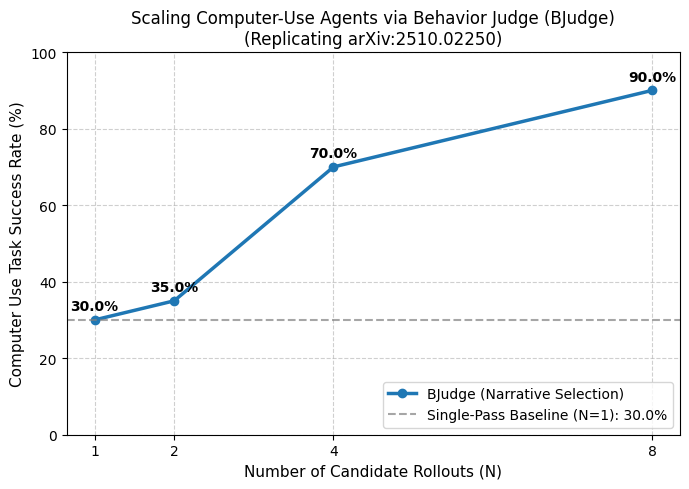

In [6]:
# [CELL 6 - BJudge Scaling Curve Plot]

def plot_bjudge_scaling(scaling_results: Dict[int, float]):
    rollouts = list(scaling_results.keys())
    accuracies = list(scaling_results.values())

    plt.figure(figsize=(7, 5))
    plt.plot(rollouts, accuracies, marker='o', linewidth=2.5, color='#1f77b4', label='BJudge (Narrative Selection)')

    # Draw OSWorld Baseline & SOTA Markers
    plt.axhline(y=accuracies[0], color='gray', linestyle='--', alpha=0.7, label=f'Single-Pass Baseline (N=1): {accuracies[0]:.1f}%')

    plt.xlabel("Number of Candidate Rollouts (N)", fontsize=11)
    plt.ylabel("Computer Use Task Success Rate (%)", fontsize=11)
    plt.title("Scaling Computer-Use Agents via Behavior Judge (BJudge)\n(Replicating arXiv:2510.02250)", fontsize=12)
    plt.xticks(rollouts)
    plt.ylim(0, 100)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='lower right')

    for r, acc in zip(rollouts, accuracies):
        plt.text(r, acc + 2.5, f"{acc:.1f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_bjudge_scaling(benchmark_scores)